# Sales Analysis

This notebook analyzes sales performance of an online retail business.

The analysis focuses on revenue dynamics, order volume, average order value, country-level performance, product-level performance and purchasing patterns by day and hour.

The goal is to understand where revenue comes from, how sales change over time, which markets and products are the strongest, and what business actions could improve growth and customer retention.

## Questions (possible)
1. How much revenue does the business generate and what is the average order value?
2. How does revenue change by month?
3. Which countries generate the most revenue?
4. How dependent is the business on the UK market?
5. Which products are the main revenue drivers?
6. Which products are sold in the highest quantities?
7. Which days and hours generate the most orders and revenue?

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

The cleaned transaction-level and order-level datasets are loaded from the `data/processed` folder.

- `online_retail_clean.csv` contains transaction lines after removing cancelled orders, invalid quantities, invalid prices and rows without customer IDs.
- `orders.csv` contains one row per invoice and is used for order-level metrics such as order count and average order value.

In [3]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

clean_path = ROOT_DIR / "data" / "processed" / "online_retail_clean.csv"
orders_path = ROOT_DIR / "data" / "processed" / "orders.csv"

df = pd.read_csv(clean_path, parse_dates=["invoice_date"])
orders = pd.read_csv(orders_path, parse_dates=["invoice_date"])

In [4]:
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled,line_revenue,invoice_day,invoice_month,invoice_year,invoice_hour,day_of_week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010-12-01,2010-12,2010,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010-12-01,2010-12,2010,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01,2010-12,2010,8,Wednesday


## 1. Executive KPI Overview

- **Total revenue** — total sales value after data cleaning.
- **Orders** — number of unique invoices.
- **Customers** — number of unique customers.
- **Products** — number of unique products sold.
- **Average order value (AOV)** — average revenue per order.
- **Orders per customer** — average number of purchases per customer.
- **Revenue per customer** — average revenue generated by one customer.

In [4]:
total_revenue = df["line_revenue"].sum()
total_orders = orders["invoice_no"].nunique()
total_customers = df["customer_id"].nunique()
total_products = df["stock_code"].nunique()
total_countries = df["country"].nunique()
aov = total_revenue / total_orders
orders_per_customer = total_orders / total_customers
revenue_per_customer = total_revenue / total_customers

kpi = pd.DataFrame(
    {
        "metric": [
            "Total revenue",
            "Orders",
            "Customers",
            "Products",
            "Countries",
            "Average order value",
            "Orders per customer",
            "Revenue per customer",
        ],
        "value": [
            total_revenue,
            total_orders,
            total_customers,
            total_products,
            total_countries,
            aov,
            orders_per_customer,
            revenue_per_customer,
        ],
    }
)

kpi

,metric,value
0,Total revenue,"8,911,407.90"
1,Orders,"18,532.00"
2,Customers,"4,338.00"
3,Products,"3,665.00"
4,Countries,37.00
5,Average order value,480.87
6,Orders per customer,4.27
7,Revenue per customer,"2,054.27"


After cleaning, the dataset contains **18,532 orders**, **4,338 customers**, **3,665 products** and **37 countries**.

The business generated approximately **£8.91M** in revenue.  
The average order value is about **£480.87**, and the average customer made **4.27 orders** during the analyzed period.

## 2. Monthly Sales Dynamics

- monthly revenue;
- number of orders;
- number of active customers;
- average order value.

In [5]:
monthly_sales = (
    orders
    .groupby("invoice_month", as_index=False)
    .agg(
        revenue=("order_revenue", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique"),
        avg_order_value=("order_revenue", "mean"),
    )
)

monthly_sales

,invoice_month,revenue,orders,customers,avg_order_value
0,2010-12,"572,713.89",1400,885,409.08
1,2011-01,"569,445.04",987,741,576.95
2,2011-02,"447,137.35",997,758,448.48
3,2011-03,"595,500.76",1321,974,450.80
4,2011-04,"469,200.36",1149,856,408.36
5,2011-05,"678,594.56",1555,1056,436.40
6,2011-06,"661,213.69",1393,991,474.67
7,2011-07,"600,091.01",1331,949,450.86
8,2011-08,"645,343.90",1280,935,504.17
9,2011-09,"952,838.38",1755,1266,542.93


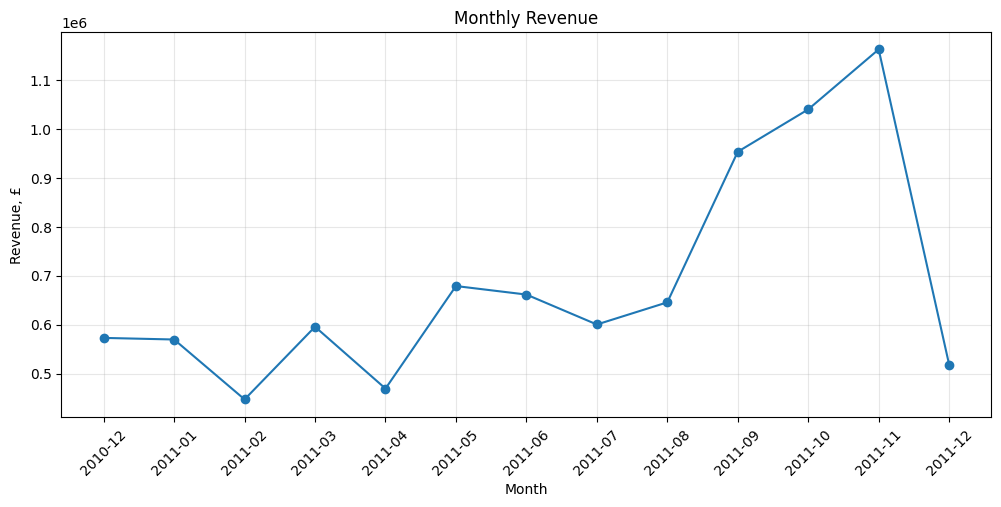

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["invoice_month"], monthly_sales["revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue, £")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

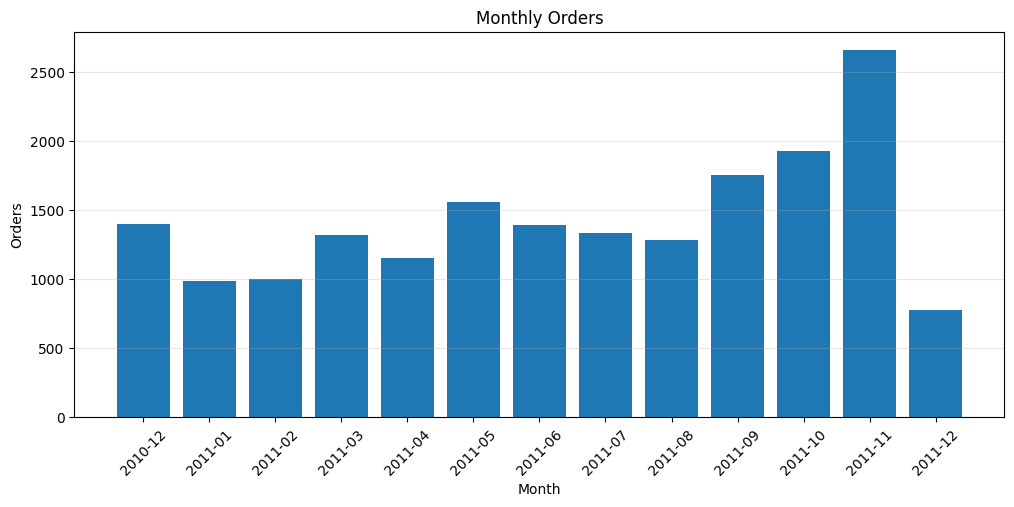

In [7]:
plt.figure(figsize=(12, 5))
plt.bar(monthly_sales["invoice_month"], monthly_sales["orders"])
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

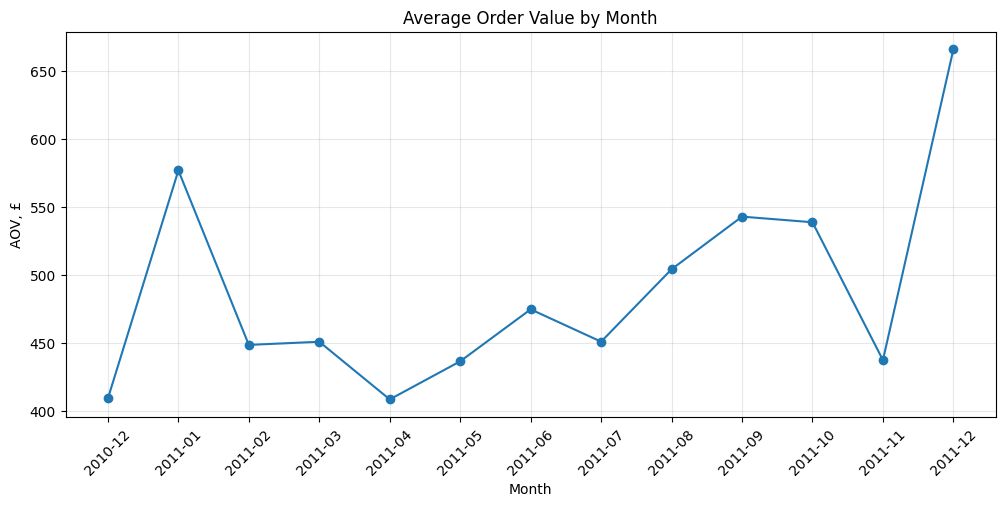

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["invoice_month"], monthly_sales["avg_order_value"], marker="o")
plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("AOV, £")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Revenue increased strongly in the second half of 2011.

Among full months, **November 2011** had the highest revenue, approximately **£1.16M**, and the highest number of orders, **2,657**.  
The strongest growth period starts around **September 2011**, which may indicate seasonal demand before the holiday period.

The drop in **December 2011** should not be interpreted as a real decline because the dataset ends on **2011-12-09**.

In the dataset, December 2011 is incomplete because the data ends on December 9, 2011.

In [9]:
monthly_sales["is_full_month"] = monthly_sales["invoice_month"] != "2011-12"

monthly_sales

,invoice_month,revenue,orders,customers,avg_order_value,is_full_month
0,2010-12,"572,713.89",1400,885,409.08,True
1,2011-01,"569,445.04",987,741,576.95,True
2,2011-02,"447,137.35",997,758,448.48,True
3,2011-03,"595,500.76",1321,974,450.80,True
4,2011-04,"469,200.36",1149,856,408.36,True
5,2011-05,"678,594.56",1555,1056,436.40,True
6,2011-06,"661,213.69",1393,991,474.67,True
7,2011-07,"600,091.01",1331,949,450.86,True
8,2011-08,"645,343.90",1280,935,504.17,True
9,2011-09,"952,838.38",1755,1266,542.93,True


In [10]:
monthly_sales_full = monthly_sales[monthly_sales["is_full_month"]].copy()

monthly_sales_full

,invoice_month,revenue,orders,customers,avg_order_value,is_full_month
0,2010-12,"572,713.89",1400,885,409.08,True
1,2011-01,"569,445.04",987,741,576.95,True
2,2011-02,"447,137.35",997,758,448.48,True
3,2011-03,"595,500.76",1321,974,450.80,True
4,2011-04,"469,200.36",1149,856,408.36,True
5,2011-05,"678,594.56",1555,1056,436.40,True
6,2011-06,"661,213.69",1393,991,474.67,True
7,2011-07,"600,091.01",1331,949,450.86,True
8,2011-08,"645,343.90",1280,935,504.17,True
9,2011-09,"952,838.38",1755,1266,542.93,True


### Full-Month Revenue Trend

The chart below excludes incomplete December 2011 and gives a cleaner view of monthly revenue dynamics.

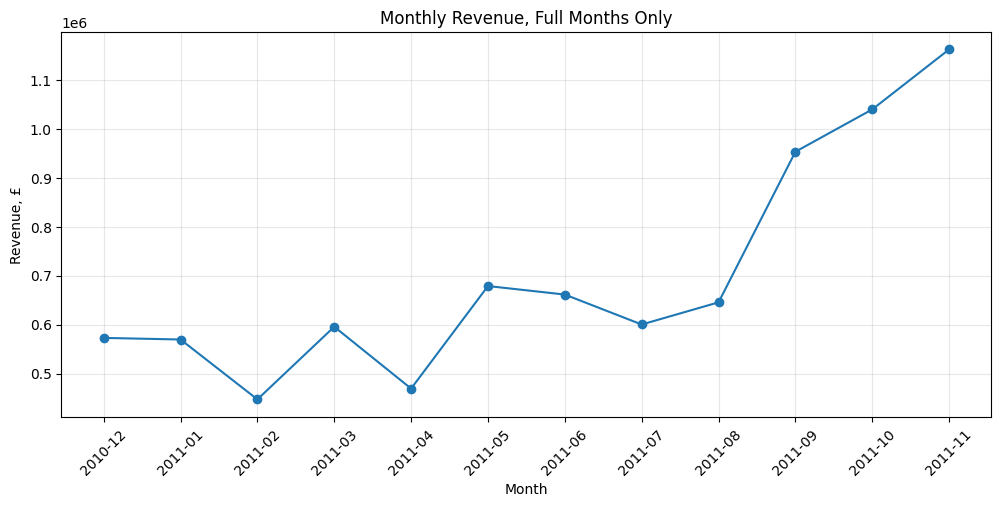

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales_full["invoice_month"], monthly_sales_full["revenue"], marker="o")
plt.title("Monthly Revenue, Full Months Only")
plt.xlabel("Month")
plt.ylabel("Revenue, £")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Country Performance

In [12]:
country_sales = (
    orders
    .groupby("country", as_index=False)
    .agg(
        revenue=("order_revenue", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique"),
        avg_order_value=("order_revenue", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

country_sales.head(15)

,country,revenue,orders,customers,avg_order_value
35,United Kingdom,"7,308,391.55",16646,3920,439.05
23,Netherlands,"285,446.34",94,9,"3,036.66"
10,EIRE,"265,545.90",260,3,"1,021.33"
14,Germany,"228,867.14",457,94,500.80
13,France,"209,024.05",389,87,537.34
0,Australia,"138,521.31",57,9,"2,430.20"
30,Spain,"61,577.11",90,30,684.19
32,Switzerland,"56,443.95",51,21,"1,106.74"
3,Belgium,"41,196.34",98,25,420.37
31,Sweden,"38,378.33",36,8,"1,066.06"


### Country-Level Findings

The business is highly concentrated in the **United Kingdom**, which generated approximately **82.01%** of total revenue.

Outside the UK, the strongest markets are **Netherlands**, **EIRE**, **Germany**, **France** and **Australia**.  
Some non-UK countries have relatively high average order value, especially **Netherlands**, **Singapore**, **Australia** and **Japan**.

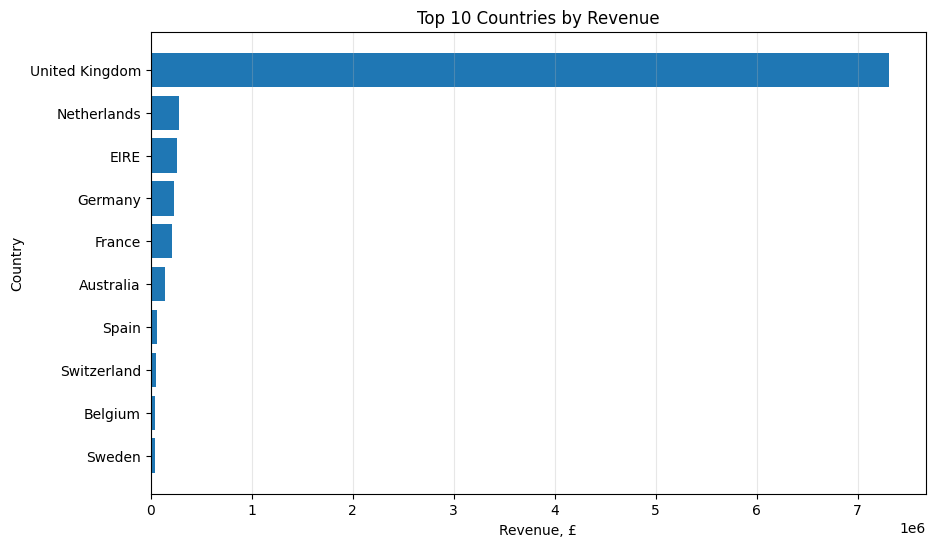

In [13]:
top_countries = country_sales.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))
plt.barh(top_countries["country"], top_countries["revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue, £")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.show()

## UK Market Concentration

Since this is a UK-based online retail business, the United Kingdom dominates the dataset.

To better understand international performance, the analysis is repeated excluding the UK.  

In [14]:
country_sales_without_uk = country_sales[country_sales["country"] != "United Kingdom"]

country_sales_without_uk.head(15)

,country,revenue,orders,customers,avg_order_value
23,Netherlands,"285,446.34",94,9,"3,036.66"
10,EIRE,"265,545.90",260,3,"1,021.33"
14,Germany,"228,867.14",457,94,500.80
13,France,"209,024.05",389,87,537.34
0,Australia,"138,521.31",57,9,"2,430.20"
30,Spain,"61,577.11",90,30,684.19
32,Switzerland,"56,443.95",51,21,"1,106.74"
3,Belgium,"41,196.34",98,25,420.37
31,Sweden,"38,378.33",36,8,"1,066.06"
19,Japan,"37,416.37",19,8,"1,969.28"


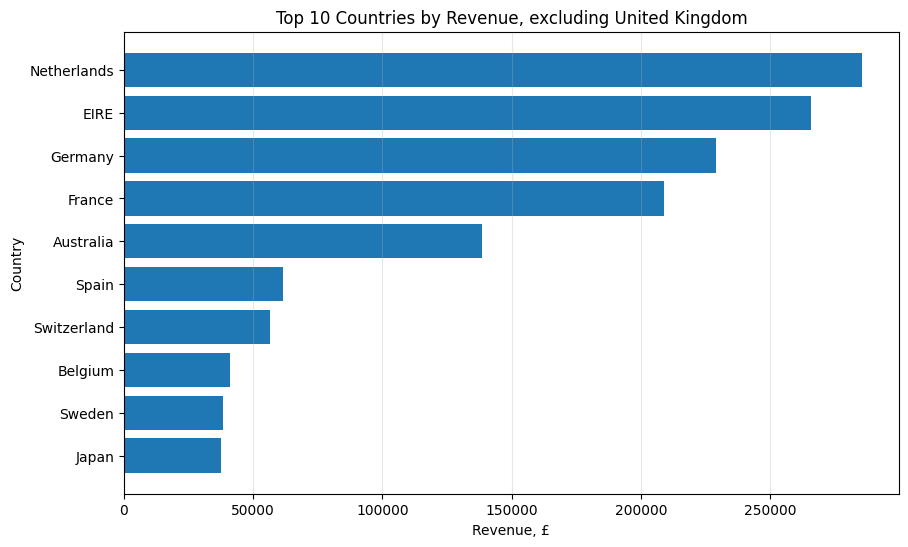

In [15]:
top_countries_without_uk = country_sales_without_uk.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))
plt.barh(top_countries_without_uk["country"], top_countries_without_uk["revenue"])
plt.title("Top 10 Countries by Revenue, excluding United Kingdom")
plt.xlabel("Revenue, £")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.show()

The UK revenue share is calculated to measure dependency on the domestic market.

In [16]:
uk_revenue = country_sales.loc[country_sales["country"] == "United Kingdom", "revenue"].iloc[0]
uk_share = uk_revenue / total_revenue

print(f"UK revenue share: {uk_share:.2%}")

UK revenue share: 82.01%


## 4. Product Performance

- **Top products by revenue** — products that contribute most to sales value.
- **Top products by quantity** — products that sell in the largest number of units.

In [17]:
product_sales = (
    df
    .groupby(["stock_code", "description"], as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        quantity=("quantity", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique"),
        avg_unit_price=("unit_price", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

product_sales.head(20)

,stock_code,description,revenue,quantity,orders,customers,avg_unit_price
2602,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08
1318,22423,REGENCY CAKESTAND 3 TIER,"142,592.95",12402,1703,881,12.48
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"100,448.15",36725,1971,856,2.89
3444,85099B,JUMBO BAG RED RETROSPOT,"85,220.78",46181,1600,635,2.02
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195,138,1.22
3896,POST,POSTAGE,"77,803.96",3120,1099,331,31.57
2799,47566,PARTY BUNTING,"68,844.33",15291,1379,708,4.88
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,"56,580.34",35362,1375,678,1.68
3894,M,Manual,"53,779.93",7173,253,197,175.29
2006,23084,RABBIT NIGHT LIGHT,"51,346.20",27202,801,450,2.01


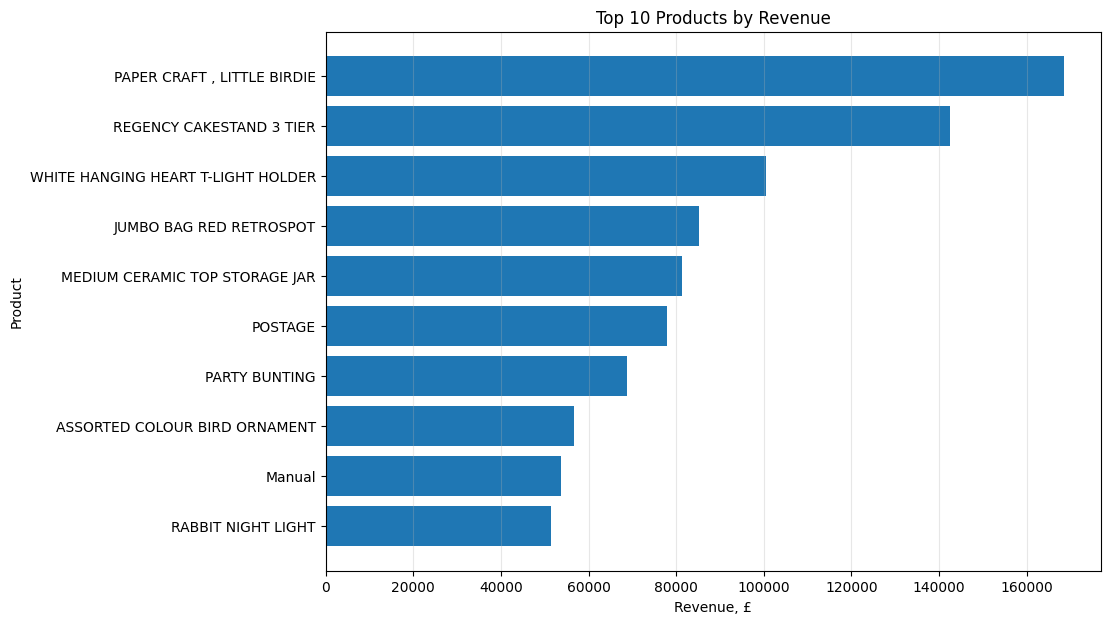

In [18]:
top_products = product_sales.head(10).sort_values("revenue")

plt.figure(figsize=(10, 7))
plt.barh(top_products["description"], top_products["revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue, £")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.show()

### Product-Level Findings

- **REGENCY CAKESTAND 3 TIER**;
- **WHITE HANGING HEART T-LIGHT HOLDER**;
- **JUMBO BAG RED RETROSPOT**;
- **PARTY BUNTING**;
- **ASSORTED COLOUR BIRD ORNAMENT**.

### Products by Quantity Sold

In [19]:
top_products_by_quantity = (
    product_sales
    .sort_values("quantity", ascending=False)
    .head(20)
)

top_products_by_quantity

,stock_code,description,revenue,quantity,orders,customers,avg_unit_price
2602,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195,138,1.22
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"13,586.25",54415,472,307,0.29
3444,85099B,JUMBO BAG RED RETROSPOT,"85,220.78",46181,1600,635,2.02
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"100,448.15",36725,1971,856,2.89
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,"56,580.34",35362,1375,678,1.68
432,21212,PACK OF 72 RETROSPOT CAKE CASES,"16,394.53",33693,1029,635,0.55
1108,22197,POPCORN HOLDER,"23,427.71",30931,632,295,0.84
2006,23084,RABBIT NIGHT LIGHT,"51,346.20",27202,801,450,2.01
1383,22492,MINI PAINT SET VINTAGE,"16,039.24",26076,325,213,0.66


## 5. Sales by Day of Week

In [20]:
orders["day_of_week"] = orders["invoice_date"].dt.day_name()

weekday_sales = (
    orders
    .groupby("day_of_week", as_index=False)
    .agg(
        revenue=("order_revenue", "sum"),
        orders=("invoice_no", "nunique"),
        avg_order_value=("order_revenue", "mean"),
    )
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_sales["day_of_week"] = pd.Categorical(
    weekday_sales["day_of_week"],
    categories=weekday_order,
    ordered=True,
)

weekday_sales = weekday_sales.sort_values("day_of_week")
weekday_sales

,day_of_week,revenue,orders,avg_order_value
1,Monday,"1,367,146.41",2863,477.52
4,Tuesday,"1,700,634.63",3184,534.12
5,Wednesday,"1,588,336.17",3455,459.72
3,Thursday,"1,976,859.07",4032,490.29
0,Friday,"1,485,917.40",2829,525.24
2,Sunday,"792,514.22",2169,365.38


### Weekday Findings

The highest revenue and order volume occur on **Thursday**, with approximately **£1.98M** revenue and **4,032 orders**.

The dataset does not show Saturday orders, which may reflect business operations, data collection logic or store schedule.  

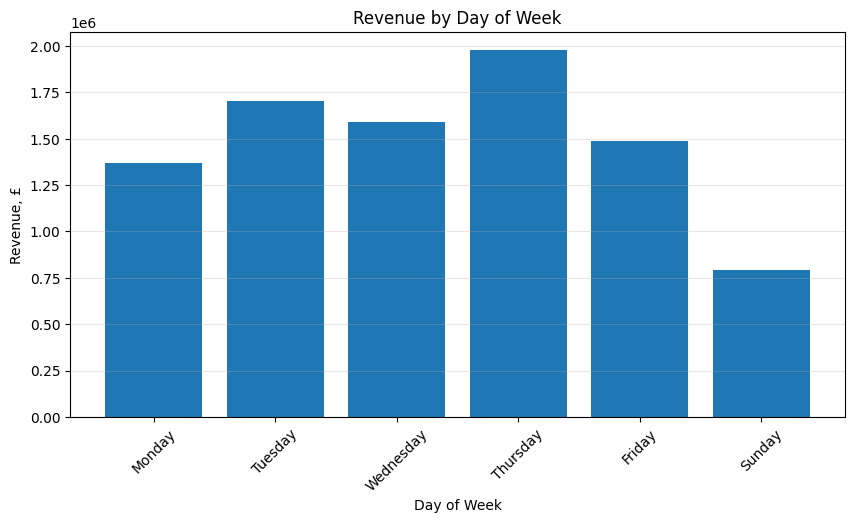

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_sales["day_of_week"], weekday_sales["revenue"])
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue, £")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Sales by Hour

Hourly analysis shows when customers are most active during the day.

In [22]:
orders["invoice_hour"] = orders["invoice_date"].dt.hour

hourly_sales = (
    orders
    .groupby("invoice_hour", as_index=False)
    .agg(
        revenue=("order_revenue", "sum"),
        orders=("invoice_no", "nunique"),
    )
)

hourly_sales

,invoice_hour,revenue,orders
0,6,4.25,1
1,7,"31,059.21",29
2,8,"282,115.63",555
3,9,"842,605.17",1393
4,10,"1,261,192.57",2226
5,11,"1,104,586.10",2277
6,12,"1,378,544.13",3129
7,13,"1,173,264.75",2636
8,14,"995,629.37",2274
9,15,"966,191.75",2037


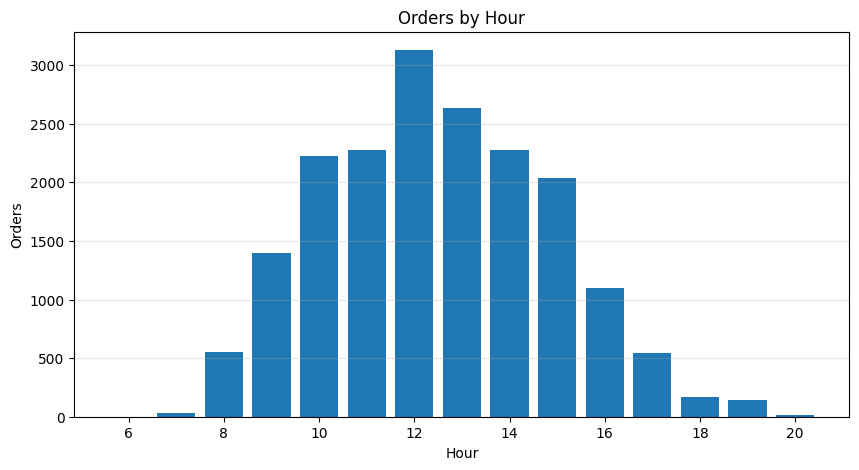

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(hourly_sales["invoice_hour"], hourly_sales["orders"])
plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Hourly Findings

Most orders are placed during business hours, especially between **10:00 and 15:00**.

The peak order hour is **12:00**, with **3,129 orders**.  
Revenue is also strongest around midday, which suggests that promotional emails or operational monitoring may be most effective during this period.

## Save Aggregated Outputs

The aggregated tables are saved to `data/processed` for future use in dashboards and reporting.

These files can be used later in DataLens or another BI tool.

In [24]:
output_dir = ROOT_DIR / "data" / "processed"

monthly_sales.to_csv(output_dir / "monthly_sales.csv", index=False)
country_sales.to_csv(output_dir / "country_sales.csv", index=False)
product_sales.to_csv(output_dir / "product_sales.csv", index=False)
weekday_sales.to_csv(output_dir / "weekday_sales.csv", index=False)
hourly_sales.to_csv(output_dir / "hourly_sales.csv", index=False)

## Findings

1. The business generated approximately **£8.91M** from **18,532 orders** and **4,338 customers**.
2. The average order value is approximately **£480.87**.
3. Revenue increased strongly in the second half of 2011, with the highest full-month revenue in **November 2011**.
4. **December 2011 is incomplete**, because the dataset ends on **2011-12-09**.
5. The business is highly dependent on the **United Kingdom**, which accounts for approximately **82.01%** of total revenue.
6. The strongest non-UK markets are **Netherlands**, **EIRE**, **Germany**, **France** and **Australia**.
7. Some products in the top revenue list may be outliers and should be reviewed before making business decisions.
8. **Thursday** is the strongest weekday by revenue and order volume.
9. Order activity is concentrated during business hours, especially around **12:00**.